# 1

In [3]:
sinucurve <- function(z, s, k) {
  z <- as.numeric(z)
  out <- numeric(length(z))
  valid <- (z > 0 & z < 1)
  if (any(valid)) {
    z_subset <- z[valid]
    out[valid] <- (sin(pi * z_subset^s))^k
  }
  out
}

.sinuarea_cache <- new.env(parent=emptyenv())
sinuarea <- function(s, k) {
  key <- paste(s, k, sep="_")
  if (exists(key, envir=.sinuarea_cache)) {
    return(.sinuarea_cache[[key]])
  }
  val <- tryCatch({
    integrate(function(z) (sin(pi * z^s))^k,
              lower=0, upper=1)$value
  }, error = function(e) {
    # Handle divergent integral - return a large value or NaN
    if (grepl("divergent", e$message)) {
      return(NaN) # Or return Inf depending on desired behavior
    } else {
      stop(e) # Re-throw other errors
    }
  })
  .sinuarea_cache[[key]] <- val
  return(val)
}

dsinustd <- function(z, s, k, flip=FALSE) {
  norm_const <- sinuarea(s, k)
  if (is.nan(norm_const) || norm_const == 0) return(numeric(length(z)))
  out <- numeric(length(z))
  valid <- (z > 0 & z < 1)
  if (!any(valid)) return(out)
  z_subset <- z[valid]
  if (flip) {
    z.f_subset <- 1 - z_subset
  } else {
    z.f_subset <- z_subset
  }
  out[valid] <- (sin(pi * z.f_subset^s))^k / norm_const
  return(out)
}

.psinustd_cache <- new.env(parent=emptyenv())
psinustd <- function(z, s, k, flip=FALSE, cache=FALSE) {
  vapply(z, FUN.VALUE=numeric(1), FUN=function(z_val) {
    if (flip) {
      return(1 - psinustd(1 - z_val, s=s, k=k, flip=FALSE, cache=cache))
    }
    if (z_val <= 0) return(0)
    if (z_val >= 1) return(1)
    if (cache) {
      key <- paste(s, k, z_val, sep="_")
      if (exists(key, envir=.psinustd_cache)) {
        return(.psinustd_cache[[key]])
      }
    }
    integral_result <- tryCatch({
      integrate(dsinustd, 0, z_val,
                                 s=s, k=k, flip=FALSE)$value
    }, error = function(e) {
       # Handle divergent integral - return NaN
      if (grepl("divergent", e$message)) {
        return(NaN) # Or return Inf
      } else {
        stop(e) # Re-throw other errors
      }
    })
    if (cache) {
      .psinustd_cache[[key]] <- integral_result
    }
    return(integral_result)
  })
}

.qsinustd_cache <- new.env(parent=emptyenv())
qsinustd <- function(p, s, k, flip=FALSE, cache=FALSE) {
  vapply(p, FUN.VALUE=numeric(1), FUN=function(p_val) {
    if (flip) {
      return(1 - qsinustd(1 - p_val, s=s, k=k, flip=FALSE, cache=cache))
    }

    if (is.na(p_val) || p_val < 0 || p_val > 1) return(NaN)
    if (p_val == 0) return(0)
    if (p_val == 1) return(1)

    if (cache) {
      key <- paste(s, k, p_val, sep="_")
      if (exists(key, envir=.qsinustd_cache)) {
        return(.qsinustd_cache[[key]])
      }
    }
    objective_f <- function(z) {
      psinustd(z, s=s, k=k, flip=FALSE, cache=cache) - p_val
    }

    root_result <- tryCatch({
      stats::uniroot(objective_f, interval=c(0, 1))$root
    }, error=function(e) { NA })

    if (cache) {
      .qsinustd_cache[[key]] <- root_result
    }
    return(root_result)
  })
}


rsinustd <- function(n, s,k,flip=FALSE) {
  qsinustd(runif(n), s, k, flip)
}

myenvir = .psinustd_cache
rm(list=ls(envir=myenvir), envir=myenvir)


dsinu = function(x, a,d,s,k,flip=F) {
  z = (x-a)/d
  pdf = 1/d * dsinustd(z, s,k,flip)
  return(pdf)
}

psinu = function(x, a,d,s,k,flip=F) {
  z = (x-a)/d
  cdf = psinustd(z, s,k,flip)
  return(cdf)
}

qsinu = function(p, a,d,s,k,flip=F) {
  qf = a + d*qsinustd(p, s,k,flip)
  return(qf)
}

rsinu <- function(n, a,d,s,k, flip =FALSE) {
  a + d*rsinustd(n, s, k, flip)
}


sinu.rmom <- function(r, a,d,s,k, flip = FALSE) {
  rmom.integrand <- function(z) {
    (a+d*z)^r * dsinustd(z, s,k,flip)
  }
  rmomVal <- tryCatch({
    integrate(rmom.integrand, lower=0, upper=1)$value
  }, error = function(e) {
    # Handle divergent integral - return NaN
    if (grepl("divergent", e$message)) {
      return(NaN) # Or return Inf
    } else {
      stop(e) # Re-throw other errors
    }
  })
  return(rmomVal)
}

.sinu.cmom_cache <- new.env(parent=emptyenv())
sinu.cmom <- function(r, a,d,s,k, flip = FALSE, cache=FALSE) {
  if (s == 0 || k == 0 || s == 1) {
    if (r %% 2 != 0) {
      return(0)
    }
    flip <- FALSE
  }

  original_flip <- flip
  key <- paste(r, s, k, sep="_")

  if (cache && exists(key, envir=.sinu.cmom_cache)) {
    unscaledCmom <- .sinu.cmom_cache[[key]]
  } else {
    stdMean <- sinu.mean(0,1,s,k, flip=FALSE)
    integrand <- function(z) {
      (z-stdMean)^r * dsinustd(z, s,k,flip=FALSE)
    }
    unscaledCmom <- tryCatch({
      integrate(integrand, lower=0, upper=1)$value
    }, error = function(e) {
      # Handle divergent integral - return NaN
      if (grepl("divergent", e$message)) {
        return(NaN) # Or return Inf
      } else {
        stop(e) # Re-throw other errors
      }
    })

    if (cache) {
      .sinu.cmom_cache[[key]] <- unscaledCmom
    }
  }

  scaledCmom <- d^r * unscaledCmom

  if (original_flip && (r %% 2 != 0)) {
    return(-scaledCmom)
  } else {
    return(scaledCmom)
  }
}

sinu.mean <- function(a,d,s,k, flip=FALSE) {
  if (s == 1 || k == 0 || s == 0) {
    return(a + d / 2)
  }
  a + d * sinu.rmom(1, 0, 1, s=s, k=k, flip=flip)
}

sinu.var <- function(a,d,s,k, flip = FALSE) {  # a unused. Mentioned for syntax consistency only.
  sinu.cmom(2, 0, d, s, k, flip)
}

sinu.skew <- function(a,d,s,k, flip = FALSE, cache=FALSE) {
  if (s == 0 || k == 0 || s == 1) {
    return(0)
  }
  cmom2 <- sinu.cmom(2, 0,1,s,k, flip, cache=cache)
  cmom3 <- sinu.cmom(3, 0,1,s,k, flip, cache=cache)
  # Check for NaN in cmom2 or cmom3 before calculating skewness
  if (is.nan(cmom2) || is.nan(cmom3) || cmom2 <= 0) {
    return(NaN)
  }
  return(cmom3 / cmom2^(3/2))
}

sinu.kurt <- function(a,d,s,k, flip = FALSE, cache=FALSE) {
  cmom2 <- sinu.cmom(2, 0,1,s,k, flip, cache=cache)
  cmom4 <- sinu.cmom(4, 0,1,s,k, flip, cache=cache)
  # Check for NaN in cmom2 or cmom4 before calculating kurtosis
  if (is.nan(cmom2) || is.nan(cmom4) || cmom2 <= 0) {
    return(NaN)
  }
  return((cmom4 / cmom2^2) - 3)
}

sinu.msm <- function(a,d,s,k, flip = FALSE) {
  measures <- c(
    sinu.mean(a, d, s, k, flip),
    sinu.var(a, d, s, k, flip),
    sinu.skew(a, d, s, k, flip),
    sinu.kurt(a, d, s, k, flip)
  )
  return(measures)
}

pmfsinu <- function(x, a,d,s,k, flip=FALSE) {  # useless function unless we give binning a serious thought
  int.vec = seq.int(floor(a+1), d) # extract integers
  int.vec
  cdf.vec = c(0, psinu(int.vec, a, d, s, k, flip))
  pmfs = diff(cdf.vec)
  pmfs[which(int.vec==x)]
}

# 2

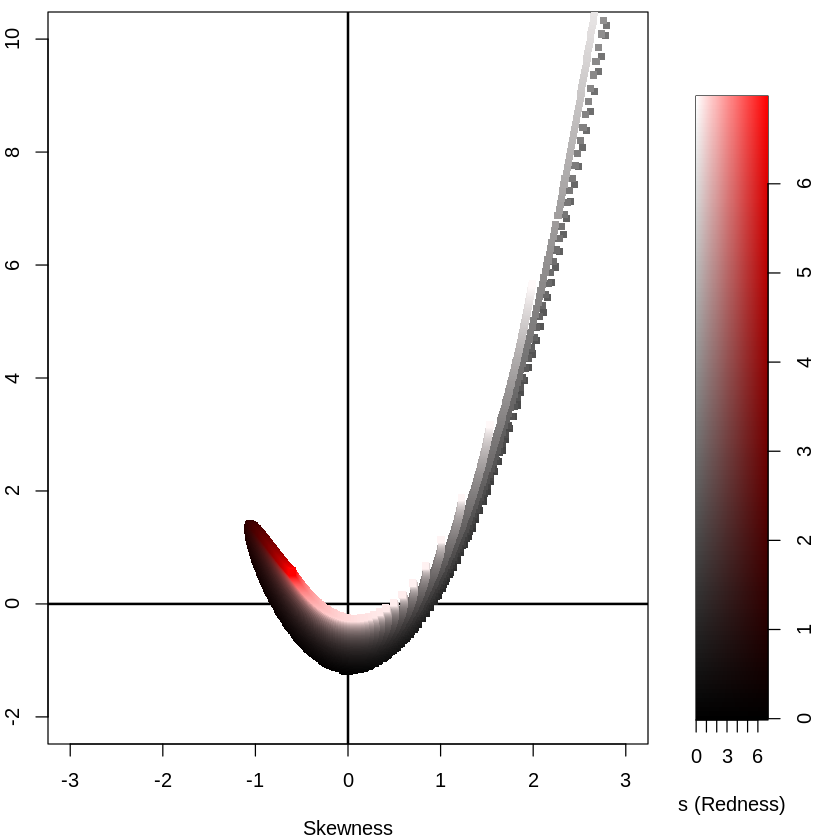

In [4]:
# --- 0. Set Batch Size ---
batch_size <- 500 # Number of points to calculate/plot at a time

# --- 1. Data Preparation ---
s.vec <- seq(0.01,7,by=0.01)
k.vec <- seq(0.01,7,by=0.01)
s.unique <- unique(s.vec)
k.unique <- unique(k.vec)
n_s <- length(s.unique)
n_k <- length(k.unique)

param.grid <- expand.grid(s = s.unique, k = k.unique)

n_rows <- nrow(param.grid)
n_batches <- ceiling(n_rows / batch_size)

# --- 2. Set up Plot Layout ---
layout(matrix(c(1, 2), 1, 2), widths=c(4, 1))

# --- 3. Create the Main Plot (Empty) ---
par(mar=c(4, 2, 0.5, 1))

# We must set fixed xlim and ylim. Adjust if your points fall outside.
plot(NULL,
     xlim = c(-3, 3),
     ylim = c(-2, 10),
     xlab = "Skewness",
     ylab = "Kurtosis (Excess)"
     )
abline(h=0, v=0, lwd=2)

# --- 4. Loop, Calculate, and Plot in Batches ---
for (i in 1:n_batches) {
  start_index <- (i - 1) * batch_size + 1
  end_index <- min(i * batch_size, n_rows)

  batch_data <- param.grid[start_index:end_index, ]

  # Calculate skew/kurt ONLY for this batch
  batch_skew <- mapply(sinu.skew, s=batch_data$s, k=batch_data$k,
                       MoreArgs=list(a=0, d=1, flip=FALSE, cache=TRUE))

  batch_kurt <- mapply(sinu.kurt, s=batch_data$s, k=batch_data$k,
                       MoreArgs=list(a=0, d=1, flip=FALSE, cache=TRUE))

  # Calculate colors ONLY for this batch
  s_norm <- (batch_data$s - min(s.unique)) / (max(s.unique) - min(s.unique))
  k_norm <- (batch_data$k - min(k.unique)) / (max(k.unique) - min(k.unique))
  batch_color <- hsv(h = 0, s = s_norm, v = k_norm)

  # Add this batch of points to the plot
  points(batch_skew, batch_kurt, col = batch_color, pch = 15, cex = 0.8)

  # Pause briefly to make the evolution visible
  Sys.sleep(0.1)
}

# --- 5. Create the 2D Legend Plot (Once at the end) ---
par(mar=c(5, 1, 4, 3))
z.index.matrix <- matrix(1:(n_s * n_k), nrow=n_s, ncol=n_k)
color.vector <- hsv(
  h=0,
  s=(rep(s.unique, n_k) - min(s.unique)) / (max(s.unique) - min(s.unique)),
  v=(rep(k.unique, each=n_s) - min(k.unique)) / (max(k.unique) - min(k.unique))
)
image(s.unique, k.unique, z.index.matrix,
      col = color.vector,
      xlab = "s (Redness)",
      ylab = "k (Luminosity)",
      yaxt = "n")
axis(4)

# Reset layout
par(mfrow=c(1,1), mar=c(5, 4, 4, 2) + 0.1)